# Chimera-47 — Theoretical Foundations

This notebook is the conceptual entry point of the project. Before any code is run, before any model is trained, this document explains **what we are doing and why**:

1. What the data looks like and what makes it hard.
2. Why TF-IDF is the right vectoriser for API-call traces.
3. Why a Support Vector Machine is theoretically the right choice for this data.
4. Why we decompose the 8-class problem into **28 binary SVMs** with a **One-vs-One voting scheme**.
5. Why we use the **soft-margin** formulation rather than hard-margin.
6. The full mathematics of the SVM, derived from scratch.
7. How we evaluate the result.
8. Multinomial Logistic Regression — softmax, cross-entropy, gradient, regularisation.
9. The first-order Markov chain classifier — chain factorisation, MLE, Laplace smoothing, log-space scoring.
10. Inductive bias — SVM vs MNLR vs Markov, side by side.

Subsequent notebooks (`01_experiment.ipynb`) work through the pipeline practically. This one is purely conceptual and self-contained.

## 1. The Data — MAL-API-2019

The dataset is **MAL-API-2019**: 7,107 Windows malware samples, each represented as a *sequence of Windows API calls* observed when the binary was detonated in a Cuckoo sandbox. Every sample carries one of **eight** family labels:

| label | family            | rough behaviour |
|-------|-------------------|------------------|
| 0     | Adware            | injects ads, redirects browsers |
| 1     | Backdoor          | opens covert remote access |
| 2     | Downloader        | fetches and runs a second-stage payload |
| 3     | Dropper           | drops embedded payloads onto disk |
| 4     | Spyware           | exfiltrates user data |
| 5     | Trojan            | impersonates a legitimate program |
| 6     | Virus             | self-replicates through file infection |
| 7     | Worm              | self-replicates over the network |

### What makes this data hard

- **Variable-length sequences.** Two samples from the same family may emit 80 or 8,000 API calls. Any classifier that wants a fixed feature vector must first map a sequence to $\mathbb{R}^d$.
- **Sparse, large vocabulary.** The full inventory of Windows API names is in the low thousands. Any single sample touches only a few percent of them.
- **Overlapping behaviour.** A Dropper that fetches a second stage looks a lot like a Downloader; a Trojan that opens a backdoor looks a lot like a Backdoor. Class boundaries are *fuzzy* — there is no clean linear separator in input space and no expectation of one.
- **Class imbalance is mild but present.** The smallest class has roughly half as many samples as the largest; not catastrophic, but enough that *stratified* sampling matters everywhere.

These three properties — variable length, sparse high-dimensional features, and fuzzy boundaries — drive every architectural decision in this project.


## 2. Vectorisation — TF-IDF over API n-grams

We treat each API-call sequence as a **document** and the API names as **tokens**. The standard text-classification pipeline applies almost without modification:

$$
\text{tf}(t, d) = \frac{\#(t \text{ in } d)}{|d|}, \qquad
\text{idf}(t) = \log \frac{1 + N}{1 + \#\{d : t \in d\}} + 1, \qquad
\text{tfidf}(t, d) = \text{tf}(t, d) \cdot \text{idf}(t).
$$

After vectorisation we apply **L2 normalisation** so that every sample lies on the unit sphere: $\|x\|_2 = 1$. Two consequences follow:

1. The dot product $x \cdot z$ becomes the cosine similarity between sequences.
2. The SVM hyperplane parameter $w$ ends up commensurable across samples, which removes one source of optimisation pathology.

### Why TF-IDF and not raw counts?

A raw bag-of-API-calls vector is dominated by extremely common system calls (`NtQuerySystemInformation`, `LdrLoadDll`) which appear in every sample regardless of family. IDF down-weights those calls and up-weights *family-specific* calls — exactly the signal we want.

### Why TF-IDF and not learned embeddings?

For ~7k samples, a learned embedding (Word2Vec / Transformer) is overkill and risks overfitting. TF-IDF is parameter-free, deterministic, fast, and empirically competitive on this dataset. We start from the strongest simple baseline and add complexity only if results demand it.

*In our codebase: `source/data/normalization/tfidf_normalizer.py`.*


## 3. Why an SVM?

We have to map sparse high-dimensional vectors with fuzzy class boundaries to one of eight labels. Several model families could in principle do this. We chose an SVM, and the choice was deliberate. Here is the case.

### Theoretical fit

- **Margin maximisation = built-in regularisation.** The SVM does not just find *some* separating hyperplane; it finds the one that maximises the distance to the nearest training points. That margin is exactly the quantity that controls generalisation in the VC / Rademacher bounds. With ~7k samples in $\mathbb{R}^{\sim 5000}$, regularisation is not a luxury.
- **Sparsity in the dual.** At the optimum, only the **support vectors** carry non-zero dual variables. Decision-time cost depends on the number of support vectors, not the size of the training set.
- **Convex objective, unique optimum.** Soft-margin SVM is a quadratic program — convex, with no local minima. Whatever the solver, you converge to the same answer (up to numerical precision).
- **No probabilistic assumption.** Logistic regression assumes the log-odds are linear in the features. Naive Bayes assumes feature independence given the class. The SVM assumes nothing about the data-generating distribution; it just looks for a wide-margin separator. With behaviour-based features whose joint distribution we have no model for, that is a feature.

### Practical fit

- **Fast on linear kernels.** `LinearSVC` solves the primal in time that scales near-linearly with the number of samples and *roughly* linearly with the number of features. For 7k samples × 5k features, a single binary SVM trains in fractions of a second.
- **Few hyperparameters.** Linear SVM has *one* hyperparameter that matters: the regularisation strength $C$. We tune it with cross-validation; that's the entire tuning loop.

This is why we chose SVM over the alternatives. The next section explains how we adapt a binary SVM to an 8-class problem.


## 4. The Architecture — 28 Binary SVMs with One-vs-One Voting

An SVM, in its standard form, is a **binary classifier**: it tells you whether a point is on the positive or negative side of a hyperplane. We have **eight** classes. We must therefore decompose the multi-class problem into a collection of binary problems and combine their answers.

### 4.1 Two standard reductions: One-vs-Rest vs One-vs-One

**One-vs-Rest (OvR):** Train $K$ binary classifiers, one per class, where each classifier separates *class $k$ from everything else*. For 8 classes: 8 models. At inference, each model emits a score; the class with the largest score wins.

*Drawbacks:* each binary problem is **highly imbalanced** (one class against seven), and the score scales of different classifiers may not be directly comparable.

**One-vs-One (OvO):** Train $\binom{K}{2}$ binary classifiers, one per *pair* of classes. Each classifier sees only the samples of its two classes and learns to separate them. For 8 classes: $\binom{8}{2} = 28$ models. At inference, every model votes for one of its two classes; majority wins.

*Advantages:* each binary problem is **balanced** (~1,780 samples per pair, roughly half from each class), each problem is **smaller and faster** to train, and SVMs scale super-linearly with sample count, so training 28 small SVMs can be **faster** than training 8 large ones.

We choose **One-vs-One**.

### 4.2 Combining the 28 votes — majority with margin tie-break

At inference, every one of the 28 binary classifiers $\text{SVM}_{(a,b)}$ looks at $x$ and votes for either class $a$ or class $b$ (the sign of its decision function). For each input we obtain a vector of 28 votes that we tally per class — the class with the most votes wins.

Pure majority vote is occasionally indecisive: two or more classes can end up tied on the vote count, especially in regions where several class boundaries are close together. To break ties without falling back to an arbitrary rule, we use the **decision-function magnitudes** — every SVM emits a real-valued score $f_{(a,b)}(x) = w_{(a,b)} \cdot x + b_{(a,b)}$ whose magnitude reflects the classifier's confidence (signed distance to the hyperplane). For each class we sum, with sign, the scores of the SVMs that involve it; the class with the largest aggregate margin among the tied set wins.

This combines the robustness of majority voting (which is insensitive to a single wrong-but-confident SVM) with the discriminating power of a continuous score (which resolves ties without coin-flipping).


## 5. Why Soft-Margin and Not Hard-Margin

An SVM has two formulations: **hard-margin** (no point may violate the margin) and **soft-margin** (violations are allowed but penalised). We use soft-margin throughout. Why?

### Hard-margin requires perfect linear separability

The hard-margin problem

$$
\min_{w, b}\; \tfrac{1}{2}\|w\|^2 \quad \text{subject to}\quad y^i(w \cdot x^i + b) \geq 1 \;\; \forall i
$$

has **no solution** if even a single training point is on the wrong side of every possible hyperplane. Real-world data — and certainly malware data, with its overlapping classes — almost never satisfies this.

### Soft-margin allows controlled violations

Soft-margin introduces a **slack variable** $\xi^i \geq 0$ for each point that measures how much that point violates the margin, and pays a penalty proportional to it:

$$
\min_{w, b, \xi}\; \tfrac{1}{2}\|w\|^2 + C \sum_{i=1}^{m} \xi^i \quad \text{subject to}\quad y^i(w \cdot x^i + b) \geq 1 - \xi^i,\;\; \xi^i \geq 0.
$$

The hyperparameter $C > 0$ is the **bias-variance knob**:

- **Large $C$**: violations are expensive → narrow margin → low bias, high variance → risk of overfitting.
- **Small $C$**: violations are cheap → wide margin → high bias, low variance → risk of underfitting.

Hard-margin is recovered as the limit $C \to \infty$ — the way we implement `HardMarginSVM` in code is exactly this: a `SoftMarginSVM` with $C = 10^6$.

### The unconstrained equivalent

At the optimum of the soft-margin problem, $\xi^i = \max(0, 1 - y^i(w \cdot x^i + b))$. Substituting back yields the **unconstrained primal** with hinge loss:

$$
\min_{w, b}\; \tfrac{1}{2}\|w\|^2 + C \sum_{i=1}^{m} \max\bigl(0,\; 1 - y^i(w \cdot x^i + b)\bigr).
$$

We derive the gradient of this objective explicitly in §6.6 — both because the derivation is short and instructive, and because it makes the optimisation behaviour transparent rather than magical.


## 6. The SVM, From Scratch

This section derives the SVM as a mathematical object, with no appeal to prior knowledge of the model. We start from the geometric definition of margin, derive the hard-margin primal, relax it to soft-margin, write down the hinge-loss form, take its gradient, build the dual, and finally show how the dual exposes the kernel trick.


### 6.1 Geometric setup — margin and the canonical hyperplane

A hyperplane in $\mathbb{R}^n$ is defined by a normal vector $w \in \mathbb{R}^n$ and a bias $b \in \mathbb{R}$:

$$
H = \{ x \in \mathbb{R}^n : w \cdot x + b = 0 \}.
$$

The **signed distance** from a point $x^i$ to $H$ is $\frac{w \cdot x^i + b}{\|w\|}$. If we adopt the convention $y^i \in \{-1, +1\}$, the **functional margin** of point $i$ is

$$
\hat\gamma^i = y^i (w \cdot x^i + b),
$$

and the **geometric margin** is $\gamma^i = \hat\gamma^i / \|w\|$. The geometric margin is invariant under rescaling $(w, b) \to (\alpha w, \alpha b)$; the functional margin is not.

We exploit that scale freedom to fix a **canonical** parameterisation: choose $(w, b)$ so that the closest training point has functional margin exactly $1$. With this choice, *every* training point satisfies

$$
y^i (w \cdot x^i + b) \geq 1,
$$

and the geometric margin of the closest point becomes $\gamma = 1 / \|w\|$. Maximising the margin is therefore equivalent to **minimising $\|w\|$** subject to the constraints above — which is the hard-margin SVM.


### 6.2 The hard-margin primal

Combining §6.1 with the convention "minimise $\|w\|$" gives the canonical hard-margin SVM:

$$
\boxed{
\min_{w, b}\; \tfrac{1}{2}\|w\|^2 \quad \text{subject to}\quad y^i(w \cdot x^i + b) \geq 1, \;\; i = 1, \dots, m.
}
$$

Three notes:

1. We minimise $\tfrac{1}{2}\|w\|^2$ rather than $\|w\|$ because the squared norm is **smooth and strictly convex**, while $\|w\|$ has a kink at zero.
2. The factor $\tfrac{1}{2}$ is cosmetic; it makes the gradient $w$ instead of $2w$.
3. The constraint set is non-empty **only if** the data is linearly separable. Otherwise the problem is infeasible — exactly the failure mode soft-margin solves.


### 6.3 The soft-margin primal

Real data is almost never linearly separable. We relax the constraints by introducing a **slack** $\xi^i \geq 0$ per point, which measures how badly that point violates the margin:

$$
\boxed{
\min_{w, b, \xi}\; \tfrac{1}{2}\|w\|^2 + C \sum_{i=1}^{m} \xi^i \quad \text{subject to}\quad y^i(w \cdot x^i + b) \geq 1 - \xi^i, \;\; \xi^i \geq 0.
}
$$

Three regimes for an individual point:

| condition                    | $\xi^i$ value          | meaning                                |
|------------------------------|------------------------|----------------------------------------|
| $y^i(w \cdot x^i + b) \geq 1$| $\xi^i = 0$            | safely outside the margin              |
| $0 < y^i(\dots) < 1$         | $\xi^i \in (0, 1)$     | inside the margin, correct side        |
| $y^i(\dots) \leq 0$          | $\xi^i \geq 1$         | misclassified                          |

The penalty $C \sum \xi^i$ is the price we pay for tolerating violations; $C$ tunes how dearly we charge for them.


### 6.4 The unconstrained primal — hinge loss

At the optimum, $\xi^i$ takes its smallest feasible value:

$$
\xi^i = \max\bigl(0, \; 1 - y^i(w \cdot x^i + b)\bigr).
$$

Substituting back collapses the constrained problem of §6.3 into a single **unconstrained** objective:

$$
\boxed{
\mathcal{L}(w, b) = \tfrac{1}{2}\|w\|^2 + C \sum_{i=1}^{m} \max\bigl(0,\; 1 - y^i(w \cdot x^i + b)\bigr).
}
$$

The function $\ell_{\text{hinge}}(z) = \max(0, 1 - z)$ is the **hinge loss**. It is zero whenever the functional margin is at least $1$, and grows linearly when it is less. The hinge loss is **convex but not differentiable** at $z = 1$; we will see in §6.6 that its subgradient suffices for first-order methods.

This form makes the next plot the most illuminating object in the entire notebook.


### 6.5 Hinge loss vs 0–1 loss — visual

The hinge loss is best understood as a **convex upper bound** on the 0-1 loss. The 0-1 loss is what we actually care about (right or wrong); the hinge loss is what we can actually optimise.


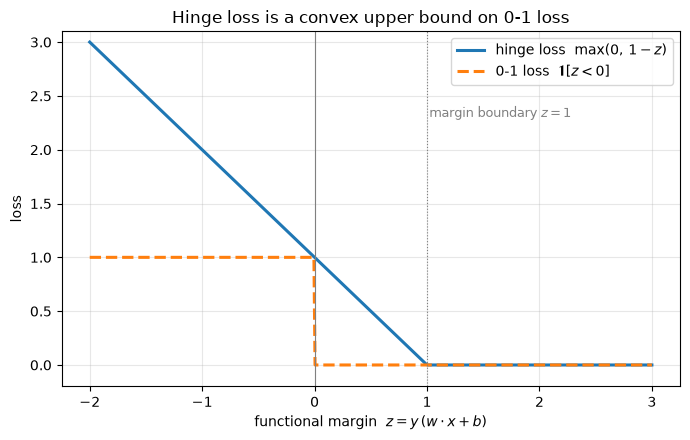

In [1]:
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-2.0, 3.0, 500)
hinge = np.maximum(0.0, 1.0 - z)
zero_one = (z < 0).astype(float)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(z, hinge, label=r'hinge loss  $\max(0,\,1-z)$', linewidth=2.2)
ax.plot(z, zero_one, label=r'0-1 loss  $\mathbb{1}[z<0]$', linewidth=2.2, linestyle='--')
ax.axvline(0.0, color='grey', linewidth=0.8)
ax.axvline(1.0, color='grey', linewidth=0.8, linestyle=':')
ax.text(1.02, 2.3, r'margin boundary $z=1$', fontsize=9, color='grey')
ax.set_xlabel(r'functional margin  $z = y\,(w\cdot x + b)$')
ax.set_ylabel('loss')
ax.set_title('Hinge loss is a convex upper bound on 0-1 loss')
ax.set_ylim(-0.2, 3.1)
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Reading the plot.** The hinge loss (solid) and the 0-1 loss (dashed) both punish $z < 0$ (misclassification). The hinge **also** punishes $0 \leq z < 1$ — points that are correctly classified but uncomfortably close to the decision boundary. That extra punishment is what produces the **margin**: minimising hinge loss does not just push points to the right side of the hyperplane, it pushes them past distance $1$ from it. The 0-1 loss has no such pressure.

The hinge loss is also **convex** — straightforwardly minimisable — whereas the 0-1 loss is non-convex and discontinuous, which is why we never optimise it directly.


### 6.6 The hinge-loss gradient — derived in scalar form

We derive $\partial \mathcal{L} / \partial w_j$ and $\partial \mathcal{L} / \partial b$ to expose the structure of the optimisation. Define for each point

$$
m^i = y^i (w \cdot x^i + b) = y^i \Bigl(\sum_{j=1}^{n} w_j x^i_j + b\Bigr).
$$

Call point $i$ a **violator** if $m^i < 1$, otherwise a **non-violator**.

**Differentiate $\frac{1}{2}\|w\|^2 = \frac{1}{2}\sum_j w_j^2$ with respect to $w_j$:** only the $w_j^2$ term contributes, giving $w_j$.

**Differentiate the hinge sum.** For non-violators, $\max(0, 1 - m^i) = 0$, so contribution is zero. For violators, $\max(0, 1 - m^i) = 1 - y^i(w \cdot x^i + b)$, and

$$
\frac{\partial}{\partial w_j}\bigl[1 - y^i(w \cdot x^i + b)\bigr] = -y^i x^i_j.
$$

Combining:

$$
\boxed{
\frac{\partial \mathcal{L}}{\partial w_j} = w_j - C \sum_{i \,:\, m^i < 1} y^i x^i_j.
}
$$

**Differentiate with respect to $b$.** The norm term has no $b$. For violators, $\partial / \partial b = -y^i$:

$$
\boxed{
\frac{\partial \mathcal{L}}{\partial b} = -C \sum_{i \,:\, m^i < 1} y^i.
}
$$

**Reading the formula.** The regulariser term $w_j$ pulls every weight toward zero. The data term pulls $w_j$ in the direction that reduces violations: a positive-class violator (large $x^i_j$, $y^i = +1$) pushes $w_j$ up; a negative-class violator pushes it down. **Non-violators contribute nothing** — once a point is safely classified, it leaves the gradient untouched. Only the **support vectors and the misclassified** drive learning.


### 6.7 The Lagrangian and the dual

The primal in §6.3 is a constrained convex QP. We can rewrite it in **dual** form using Lagrange multipliers — the form in which the **kernel trick** appears naturally.

Introduce one multiplier $\alpha^i \geq 0$ per margin constraint and one $\mu^i \geq 0$ per slack non-negativity constraint:

$$
\mathcal{L}_P(w, b, \xi, \alpha, \mu) = \tfrac{1}{2}\|w\|^2 + C\sum_i \xi^i - \sum_i \alpha^i\bigl[y^i(w \cdot x^i + b) - 1 + \xi^i\bigr] - \sum_i \mu^i \xi^i.
$$

Setting $\partial \mathcal{L}_P / \partial w = 0$, $\partial \mathcal{L}_P / \partial b = 0$, $\partial \mathcal{L}_P / \partial \xi^i = 0$ gives the **stationarity** conditions:

$$
w = \sum_i \alpha^i y^i x^i, \qquad \sum_i \alpha^i y^i = 0, \qquad \alpha^i + \mu^i = C.
$$

Substituting back eliminates $w$, $b$, $\xi$ and yields the **dual**:

$$
\boxed{
\max_{\alpha} \; W(\alpha) = \sum_{i=1}^m \alpha^i - \tfrac{1}{2}\sum_{i, n} \alpha^i \alpha^n y^i y^n (x^i \cdot x^n) \quad \text{s.t.}\quad 0 \leq \alpha^i \leq C, \;\; \sum_i \alpha^i y^i = 0.
}
$$

Three structural observations:

1. The dual is a **quadratic program in $m$ variables** — one per training sample — regardless of the input dimension.
2. The data appears **only as inner products** $x^i \cdot x^n$. This is the doorway to kernels (§6.8).
3. By complementary slackness, $\alpha^i > 0$ implies the constraint is tight — i.e. $x^i$ is on or inside the margin. These are the **support vectors**, and $w$ is a linear combination of them alone.


### 6.8 The kernel trick (conceptual)

The dual depends on data only through inner products. So, for any function $K(x, z) = \varphi(x) \cdot \varphi(z)$ that corresponds to an inner product in *some* (possibly very high-dimensional or even infinite-dimensional) feature space, we can substitute $K(x^i, x^n)$ wherever $x^i \cdot x^n$ appears:

$$
W(\alpha) = \sum_i \alpha^i - \tfrac{1}{2}\sum_{i, n} \alpha^i \alpha^n y^i y^n K(x^i, x^n), \quad f(x) = \sum_i \alpha^i y^i K(x^i, x) + b.
$$

We obtain a **non-linear** classifier in the original space without ever computing $\varphi$. Famous examples:

- Polynomial kernel $K(x, z) = (x \cdot z + c)^p$ — corresponds to lifting into the space of all monomials up to degree $p$.
- Gaussian (RBF) kernel $K(x, z) = \exp(-\gamma \|x - z\|^2)$ — corresponds to lifting into an infinite-dimensional feature space.

**Why we do not use kernels in this project.** TF-IDF features are already high-dimensional and approximately linearly separable for this kind of data, so a linear SVM is empirically sufficient. Linear is the right starting point for text-like inputs.


### 6.9 Soft-margin geometry — visual

A picture of what soft-margin actually buys us. We simulate two overlapping Gaussian classes in $\mathbb{R}^2$, train a linear SVM, and draw the hyperplane, the two margin lines, and the support vectors.


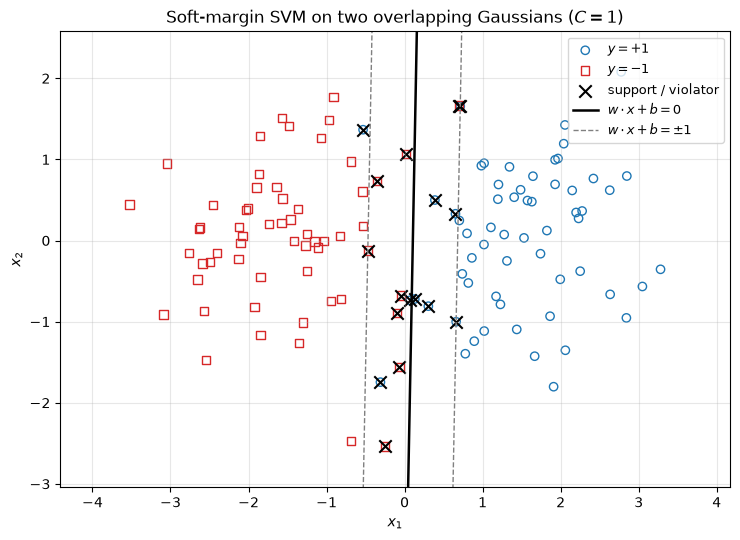

support / violator points: 17 / 120
||w|| = 1.740, geometric margin 1/||w|| = 0.575


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC

rng = np.random.default_rng(47)
n = 60
X_pos = rng.normal(loc=( 1.4, 0.0), scale=0.9, size=(n, 2))
X_neg = rng.normal(loc=(-1.4, 0.0), scale=0.9, size=(n, 2))
X = np.vstack([X_pos, X_neg])
y = np.concatenate([np.ones(n), -np.ones(n)])

clf = LinearSVC(C=1.0, loss='hinge', max_iter=10000, tol=1e-6).fit(X, y)
w = clf.coef_.ravel()
b = float(clf.intercept_[0])

xx = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200)
boundary = -(w[0] * xx + b) / w[1]
upper    = -(w[0] * xx + b - 1) / w[1]
lower    = -(w[0] * xx + b + 1) / w[1]

functional_margin = y * (X @ w + b)
support_mask = functional_margin <= 1.0 + 1e-3

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.scatter(X_pos[:, 0], X_pos[:, 1], marker='o', edgecolors='C0', facecolors='none', label=r'$y = +1$')
ax.scatter(X_neg[:, 0], X_neg[:, 1], marker='s', edgecolors='C3', facecolors='none', label=r'$y = -1$')
ax.scatter(X[support_mask, 0], X[support_mask, 1], marker='x', s=80, color='black', label='support / violator')
ax.plot(xx, boundary, color='black', linewidth=1.8, label=r'$w \cdot x + b = 0$')
ax.plot(xx, upper, color='grey', linestyle='--', linewidth=1.0, label=r'$w \cdot x + b = \pm 1$')
ax.plot(xx, lower, color='grey', linestyle='--', linewidth=1.0)
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_title(r'Soft-margin SVM on two overlapping Gaussians ($C = 1$)')
ax.set_ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'support / violator points: {int(support_mask.sum())} / {len(X)}')
print(f'||w|| = {np.linalg.norm(w):.3f}, geometric margin 1/||w|| = {1.0/np.linalg.norm(w):.3f}')


**Reading the plot.** The black solid line is the decision boundary $w \cdot x + b = 0$. The two grey dashed lines are the margin boundaries $w \cdot x + b = \pm 1$. Points marked `x` are either **support vectors** (sitting exactly on a margin line) or **violators** (inside the margin, possibly on the wrong side). Points safely outside the margin contribute *nothing* to the gradient — exactly the sparsity property derived in §6.6.

Notice that the SVM does not try to push the boundary away from the bulk of each class. It only cares about the **closest** points: the support vectors set the margin, and the rest of the training set is essentially invisible to the solver. This is the geometric content of the dual representation $w = \sum_i \alpha^i y^i x^i$ with $\alpha^i \neq 0$ only for support vectors.


## 7. Evaluation Metrics

Once we have an 8-class predictor, we have to score it. We use five complementary measurements; together they characterise the model from different angles.

### 7.1 Accuracy
$$
\text{accuracy} = \frac{\#\text{correct predictions}}{\#\text{predictions}}.
$$

The headline number, but a misleading one in isolation: a classifier that always predicts the majority class achieves an accuracy equal to the majority-class frequency without learning anything useful.

### 7.2 Precision (per class, then macro-averaged)
$$
\text{precision}_k = \frac{\text{TP}_k}{\text{TP}_k + \text{FP}_k}, \qquad
\text{macro-precision} = \frac{1}{K} \sum_{k=1}^K \text{precision}_k.
$$

Of all the times we predicted class $k$, what fraction were correct? Macro-averaging gives every class equal weight regardless of frequency — robust to class imbalance.

### 7.3 Recall (per class, then macro-averaged)
$$
\text{recall}_k = \frac{\text{TP}_k}{\text{TP}_k + \text{FN}_k}, \qquad
\text{macro-recall} = \frac{1}{K} \sum_{k=1}^K \text{recall}_k.
$$

Of all the actual class-$k$ samples, what fraction did we catch? Again macro-averaged for class-imbalance robustness.

### 7.4 F1 (harmonic mean, per class, then macro)
$$
\text{F1}_k = \frac{2 \cdot \text{precision}_k \cdot \text{recall}_k}{\text{precision}_k + \text{recall}_k}, \qquad
\text{macro-F1} = \frac{1}{K} \sum_{k=1}^K \text{F1}_k.
$$

The harmonic mean penalises classes where either precision or recall is low — a class with precision 0.95 and recall 0.05 has F1 ≈ 0.10, not 0.50. Macro-F1 is the headline single-number metric for multi-class problems with class imbalance.

### 7.5 Confusion matrix

A $K \times K$ table where $C_{ij}$ is the number of samples whose true class is $i$ and whose predicted class is $j$. The diagonal is correct predictions; the off-diagonal cells reveal **which classes get confused for which** — the qualitative information that the scalar metrics above hide. For 8 malware families with overlapping behaviour, the confusion matrix is often more useful than any single number.

*In our codebase: `source/evaluations/` (`accuracy_metric.py`, `macro_precision_metric.py`, `macro_recall_metric.py`, `macro_f1_metric.py`, `confusion_matrix.py`).*


## 8. A Second Discriminative Lens — Multinomial Logistic Regression

The SVM is a **discriminative, geometric** model: it draws a boundary that maximises a margin and never asks how the data was generated. Multinomial Logistic Regression (MNLR) is the **discriminative, probabilistic** sibling — same linear hypothesis class, same TF-IDF features, but it models $P(y \mid x)$ directly via the softmax instead of placing a margin in input space. The math below derives MNLR from first principles, then explains exactly where its inductive bias diverges from the SVM's.

### 8.1 The hypothesis — softmax over $K$ linear scores

We assign one weight vector per class, $w_k \in \mathbb{R}^n$, and one bias $b_k \in \mathbb{R}$, $k = 1, \dots, K$. The **logit** for class $k$ on input $x$ is the linear score

$$
z_k(x) = w_k \cdot x + b_k.
$$

We turn the $K$ logits into a probability distribution over classes through the **softmax**:

$$
\boxed{
P(y = k \mid x; W, b) = \frac{\exp(z_k(x))}{\sum_{j=1}^{K} \exp(z_j(x))}.
}
$$

Three properties drop out for free:

1. **Non-negativity and normalisation.** $P(y = k \mid x) \geq 0$ and $\sum_k P(y = k \mid x) = 1$ — the output is a valid distribution by construction.
2. **Shift invariance.** Adding the same constant to every logit leaves the softmax unchanged: $\text{softmax}(z) = \text{softmax}(z + c\,\mathbf{1})$. This is what we exploit numerically by subtracting $\max_j z_j$ before exponentiating, to avoid overflow.
3. **Reduction to logistic.** With $K = 2$, set $w = w_1 - w_0$ and $b = b_1 - b_0$; the softmax collapses to $\sigma(w \cdot x + b)$ — the binary logistic sigmoid. MNLR is the genuine multi-class generalisation, not a stitched-together cluster of one-vs-rest sigmoids.

### 8.2 The loss — negative log-likelihood / cross-entropy

We fit $W = (w_1, \dots, w_K)$ and $b = (b_1, \dots, b_K)$ by **maximum likelihood**. Encode each label as a one-hot vector $y^i \in \{0,1\}^K$. The likelihood of the training set under the model is

$$
L(W, b) = \prod_{i=1}^{m} \prod_{k=1}^{K} P(y = k \mid x^i)^{y^i_k}.
$$

Take the negative log to turn the product into a sum and the maximisation into a minimisation:

$$
\boxed{
\mathcal{L}_{\text{CE}}(W, b) \;=\; -\sum_{i=1}^{m} \sum_{k=1}^{K} y^i_k \, \log P(y = k \mid x^i; W, b).
}
$$

This is the **categorical cross-entropy loss**. Since $y^i$ is one-hot, the inner sum collapses: only the term for the true class $c^i$ survives, and we are minimising $-\sum_i \log P(y = c^i \mid x^i)$ — the negative log-probability the model assigns to the *correct* answer.

**Why this loss and not 0-1 or hinge?** Like the hinge loss, cross-entropy is a **convex surrogate** for 0-1 loss. Unlike hinge, it is *strictly* convex (under L2 regularisation), smooth, and rewards calibrated confidence rather than a fixed margin. A correct prediction with $P = 0.55$ still incurs non-trivial loss; a correct prediction with $P = 0.99$ pays almost nothing. Cross-entropy keeps pushing the optimiser to be more *confident* even after a sample is correctly classified — the SVM stops caring once $z \geq 1$.

### 8.3 The gradient — derived

We derive $\partial \mathcal{L}_{\text{CE}} / \partial w_k$ to expose the optimisation structure (and to make plain that MNLR is a convex problem with a closed-form gradient — not a mystery).

Drop the regulariser for the moment and work with one sample $i$. Let $p^i_k = P(y = k \mid x^i)$. The per-sample loss is $-\sum_k y^i_k \log p^i_k$. Differentiate with respect to a logit $z^i_\ell = w_\ell \cdot x^i + b_\ell$:

$$
\frac{\partial p^i_k}{\partial z^i_\ell} = p^i_k (\delta_{k\ell} - p^i_\ell), \qquad
\frac{\partial}{\partial z^i_\ell}\!\left[-\sum_k y^i_k \log p^i_k\right] = p^i_\ell - y^i_\ell.
$$

The right-hand side is a clean and famous result: the gradient with respect to the logits is exactly the **prediction error** $p - y$. Chain through to $w_\ell$ via $z^i_\ell = w_\ell \cdot x^i + b_\ell$:

$$
\boxed{
\frac{\partial \mathcal{L}_{\text{CE}}}{\partial w_\ell} = \sum_{i=1}^{m} (p^i_\ell - y^i_\ell)\, x^i, \qquad
\frac{\partial \mathcal{L}_{\text{CE}}}{\partial b_\ell} = \sum_{i=1}^{m} (p^i_\ell - y^i_\ell).
}
$$

**Reading the formula.** Each training point contributes to $w_\ell$ in the direction $x^i$, weighted by *how wrong* the model currently is about whether $i$ belongs to class $\ell$. Confident-and-correct points contribute almost nothing ($p \approx y$). Confident-and-wrong points contribute a lot ($p$ far from $y$). The optimisation moves weights to flip those confident-wrong predictions first.

Contrast with §6.6: the SVM gradient is sparse — only **violators** drive learning. The MNLR gradient is **dense** — every point contributes a small residual. Discriminative-probabilistic vs discriminative-geometric: same hypothesis class, different signal.

### 8.4 Regularisation — L2 penalty

The unregularised loss has a degeneracy: as we noted, softmax is shift-invariant, so we can add the same constant to every $w_k$ without changing predictions. To pin down a unique minimiser, we add an L2 penalty:

$$
\mathcal{L}(W, b) = \frac{1}{C}\,\frac{1}{2}\sum_{k=1}^{K}\|w_k\|^2 \;+\; \sum_{i=1}^{m}\bigl[-\log P(y = c^i \mid x^i)\bigr].
$$

The hyperparameter $C > 0$ plays exactly the same role as in soft-margin SVM:

- **Large $C$** → weak regularisation → low bias, high variance.
- **Small $C$** → strong regularisation → high bias, low variance.

Sklearn's `LogisticRegression(C=...)` parameterises it identically, which is why our experiment notebook sweeps $C$ over the same logarithmic grid for both models.

*In our codebase:* `source/models/logistic_regression/multinomial_logistic_regression.py`. The implementation wraps `sklearn.linear_model.LogisticRegression` with the `lbfgs` solver — quasi-Newton optimisation against the convex objective above.

### 8.5 The softmax — visual

A picture of how three logits on $\mathbb{R}$ are turned into a probability simplex over three classes. The inputs are $(z_1, z_2, z_3)$ varying along an axis; the outputs are softmax probabilities.

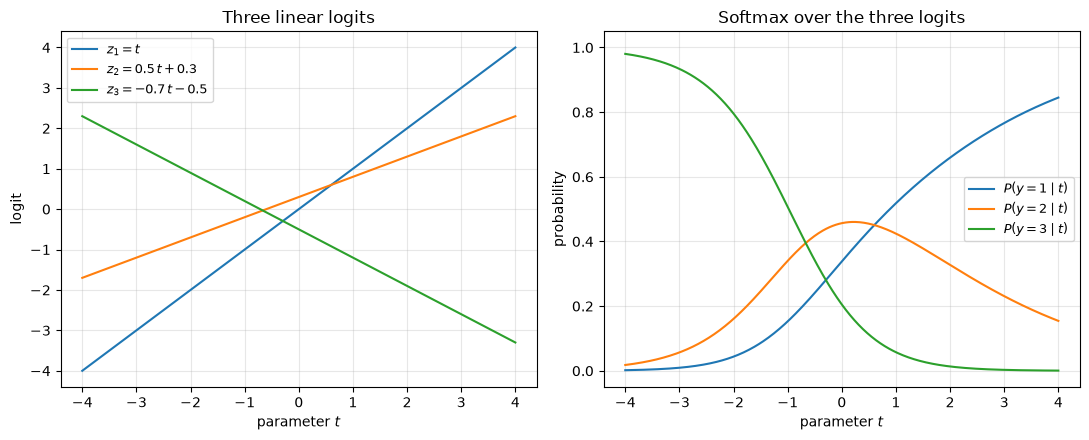

row sums: min=1.000000, max=1.000000


In [3]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(-4.0, 4.0, 400)
z1 =  t
z2 =  0.5 * t + 0.3
z3 = -0.7 * t - 0.5
Z = np.vstack([z1, z2, z3])

Z_shifted = Z - Z.max(axis=0, keepdims=True)
expZ = np.exp(Z_shifted)
P = expZ / expZ.sum(axis=0, keepdims=True)

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11, 4.5))

ax_left.plot(t, z1, label=r'$z_1 = t$')
ax_left.plot(t, z2, label=r'$z_2 = 0.5\,t + 0.3$')
ax_left.plot(t, z3, label=r'$z_3 = -0.7\,t - 0.5$')
ax_left.set_xlabel(r'parameter $t$')
ax_left.set_ylabel('logit')
ax_left.set_title('Three linear logits')
ax_left.legend(loc='upper left', fontsize=9)
ax_left.grid(alpha=0.3)

ax_right.plot(t, P[0], label=r'$P(y=1\mid t)$')
ax_right.plot(t, P[1], label=r'$P(y=2\mid t)$')
ax_right.plot(t, P[2], label=r'$P(y=3\mid t)$')
ax_right.set_xlabel(r'parameter $t$')
ax_right.set_ylabel('probability')
ax_right.set_title('Softmax over the three logits')
ax_right.set_ylim(-0.05, 1.05)
ax_right.legend(loc='center right', fontsize=9)
ax_right.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'row sums: min={P.sum(axis=0).min():.6f}, max={P.sum(axis=0).max():.6f}')

**Reading the plot.** The left panel shows three linear logits over a one-dimensional input. The right panel shows the softmax of those logits — three smooth curves that together sum to $1$ everywhere. Notice three things: (a) the curves never cross zero or one — softmax outputs are strictly inside $(0, 1)$; (b) where two logits cross, the corresponding probabilities cross at $0.5$; (c) the probability assigned to the largest logit is *not* one — softmax is a **soft** maximum, not the argmax. The temperature of the softmax is implicit in the magnitude of the logits: doubling all logits sharpens the distribution toward one-hot, halving them flattens it toward uniform. That magnitude is exactly what L2 regularisation controls.

## 9. A Generative Lens — First-Order Markov Chain Classifier

Both the SVM and MNLR work on TF-IDF vectors — they throw away order. A malware trace is a *sequence*, and the order of API calls might carry signal: `OpenFile → ReadFile → CloseFile` says something different from `CloseFile → ReadFile → OpenFile`. The Markov-chain classifier is the simplest possible model that uses sequence order: per family, fit a **first-order Markov chain** over API tokens, then classify a new sequence by which family's chain assigns it the highest log-likelihood. It is also a different *kind* of model — **generative**, modelling $P(x \mid y)$ rather than $P(y \mid x)$ directly.

### 9.1 The model — chain factorisation per class

Let $V$ denote the API-call vocabulary, $|V| = N$. A first-order Markov chain over $V$ is parameterised by:

- an **initial distribution** $\pi \in \Delta^{N-1}$ with $\pi_t = P(X_1 = t)$,
- a **transition matrix** $A \in [0,1]^{N \times N}$ with $A_{tu} = P(X_{r+1} = u \mid X_r = t)$ and rows summing to $1$.

Under the **first-order Markov assumption**

$$
P(X_{r+1} \mid X_r, X_{r-1}, \dots, X_1) = P(X_{r+1} \mid X_r),
$$

the joint probability of an observed sequence $x = (x_1, x_2, \dots, x_T)$ factorises as

$$
\boxed{
P(x; \pi, A) = \pi_{x_1} \, \prod_{r=1}^{T-1} A_{x_r,\,x_{r+1}}.
}
$$

In words: the first token comes from the initial distribution, and every subsequent token is conditionally independent of the past *given* the immediately previous token. Real API-call traces are not Markov in the strict sense — there are real long-range dependencies — but a first-order chain is a useful, computationally trivial first cut.

We fit **one chain per class**: parameters $(\pi^{(k)}, A^{(k)})$ for each malware family $k$. A new sequence $x$ is scored under each class's model and assigned to the class with the largest score:

$$
\hat y(x) = \arg\max_{k}\; \log P(x; \pi^{(k)}, A^{(k)}).
$$

(With uniform class priors. We use uniform here because macro-F1 already weights every class equally, but in principle one would multiply by $P(y = k)$ to recover the full Bayes classifier.)

### 9.2 Maximum-likelihood estimation — counts and ratios

Fitting a Markov chain by maximum likelihood is gratifyingly simple. For class $k$ with training sequences $\mathcal{D}_k = \{x^{(i)}\}$, define count statistics

$$
n^{(k)}_t = \#\{i : x^{(i)}_1 = t\}, \qquad
n^{(k)}_{tu} = \sum_{i \in \mathcal{D}_k} \#\{r : x^{(i)}_r = t,\, x^{(i)}_{r+1} = u\}.
$$

Maximising $\log P(\mathcal{D}_k; \pi, A)$ subject to row-stochasticity (Lagrange multipliers, one per row) yields the textbook MLE:

$$
\hat\pi^{(k)}_t = \frac{n^{(k)}_t}{\sum_{t'} n^{(k)}_{t'}}, \qquad
\hat A^{(k)}_{tu} = \frac{n^{(k)}_{tu}}{\sum_{u'} n^{(k)}_{tu'}}.
$$

Initial probabilities are sample frequencies of the first token; transition probabilities are normalised counts of consecutive-pair occurrences. There is no iterative optimisation, no convergence criterion — closed-form, one pass over the data.

### 9.3 The zero-probability problem and Laplace smoothing

Pure MLE has a fatal flaw. If a transition $t \to u$ is *never* seen in class $k$'s training data, $\hat A^{(k)}_{tu} = 0$. Then for any test sequence containing the bigram $t u$, $P(x; \pi^{(k)}, A^{(k)}) = 0$ and $\log P = -\infty$ — a single unseen bigram disqualifies the class entirely, no matter how well every other transition fits.

Real API-call vocabularies have hundreds of tokens and therefore tens of thousands of possible bigrams; many are rare and will not appear in any single class's training set even though they are perfectly plausible. The zero-probability problem is not an edge case; it is the default.

**Laplace (additive) smoothing** fixes it by adding a small pseudo-count $\alpha > 0$ to every cell before normalising:

$$
\boxed{
\tilde\pi^{(k)}_t = \frac{n^{(k)}_t + \alpha}{\sum_{t'} (n^{(k)}_{t'} + \alpha)}, \qquad
\tilde A^{(k)}_{tu} = \frac{n^{(k)}_{tu} + \alpha}{\sum_{u'} (n^{(k)}_{tu'} + \alpha)}.
}
$$

Two equivalent interpretations:

1. **Frequentist regularisation.** The pseudo-count $\alpha$ pulls every estimate toward the uniform distribution; $\alpha \to 0$ recovers MLE, $\alpha \to \infty$ flattens every transition to $1/N$.
2. **Bayesian.** Laplace smoothing is the *posterior mean* under a Dirichlet$(\alpha, \dots, \alpha)$ prior on each row of $A$ (and on $\pi$). $\alpha$ is the prior strength.

We additionally reserve a special **`UNK` index** so that test-time tokens unseen during training have a defined index and contribute through the smoothed mass rather than crashing the model.

*In our codebase:* `source/models/markov_chain/markov_chain_classifier.py`. The hyperparameter `smoothing_alpha` is exactly the $\alpha$ above.

### 9.4 Scoring in log-space

Multiplying $T - 1 \sim 10^3$ probabilities all smaller than $1$ underflows to zero immediately. We work in **log-space**: take the log of the chain factorisation in §9.1 to convert the product into a sum,

$$
\log P(x; \pi^{(k)}, A^{(k)}) = \log \tilde\pi^{(k)}_{x_1} + \sum_{r=1}^{T-1} \log \tilde A^{(k)}_{x_r,\, x_{r+1}}.
$$

All quantities are negative finite numbers. Per-class log-likelihoods over a test set form an $(m, K)$ matrix; argmax-along-rows gives the prediction. The decision rule reduces to a single dot-product-like operation per class once the smoothed log-tables are precomputed at fit time.

## 10. Inductive Bias — SVM vs MNLR vs Markov

All three models map an API-call sequence to one of eight family labels. They disagree on **what shape that mapping should take**. The shape is what statisticians call the *inductive bias* — the set of solutions the model is willing to consider. A model whose bias matches the structure of the problem is the right model; one whose bias does not, is not.

### 10.1 The three families at a glance

| | **OvO + 28 SVMs** | **MNLR** | **First-order Markov** |
|---|---|---|---|
| Family | Discriminative | Discriminative | **Generative** |
| Models | $\text{sign}(w \cdot x + b)$, pairwise | $P(y \mid x)$ via softmax | $P(x \mid y)$ via chain factorisation |
| Input representation | TF-IDF vector (order-free) | TF-IDF vector (order-free) | Raw token sequence (order-aware) |
| Loss / fit | Hinge loss + L2 | Cross-entropy + L2 | Closed-form MLE + Laplace smoothing |
| Convex? | Yes | Yes (strictly) | N/A (closed-form) |
| Multi-class strategy | OvO decomposition (28 binaries + voting) | Native (single softmax) | Native (one chain per class, argmax log-likelihood) |
| Output | Vote count + signed margins | Calibrated probability over 8 classes | Per-class log-likelihood, no calibration |
| Parameter count | $28 \cdot (n+1)$ | $K \cdot (n+1)$ | $K \cdot N \cdot (N + 1)$ |
| What drives the gradient / fit | Support vectors and violators only | Every sample, weighted by residual $p - y$ | Bigram counts (one pass over data) |
| Hyperparameter that matters | $C$ (margin / regularisation) | $C$ (regularisation strength) | $\alpha$ (smoothing) |

### 10.2 Discriminative vs generative

**Discriminative** models (SVM, MNLR) directly model the boundary between classes: $P(y \mid x)$ for MNLR, and $\text{sign}(w \cdot x + b)$ for SVM (no probability, just the sign). They make no claim about how $x$ was generated. As a result they tend to be more accurate when training data is plentiful and the boundary is the only thing we need.

**Generative** models (Markov) model the full joint $P(x, y)$ via $P(x \mid y) P(y)$, then invert with Bayes' rule. They make stronger assumptions — here, that token order follows a first-order Markov chain — and so they need fewer samples to fit *if the assumption is correct*. They also let you do things discriminative models cannot: sample new sequences from a class, detect out-of-distribution inputs by low likelihood under every class, build hybrid models with HMMs.

**Practical consequence.** When the generative assumption is right, generative wins on small data. When it is wrong, the discriminative model has the larger hypothesis class and wins on large data. Our experiment shows the discriminative pair (SVM 0.59, MNLR 0.57 macro-F1) beating the Markov chain (0.37): the first-order Markov assumption is too local to capture family-level structure, and TF-IDF + linear is empirically a better fit.

### 10.3 Margin vs likelihood — same hypothesis class, different objective

SVM and MNLR draw their boundary from the **same** hypothesis class — linear functions of $x$. Their disagreement is over what makes a boundary good.

**SVM** maximises the *margin*: the geometric distance from the boundary to the closest training point. Once a point is past distance $1$ from the hyperplane, the hinge loss is zero and the point exerts no further influence. The optimisation is therefore driven entirely by **support vectors and violators**.

**MNLR** maximises the *log-likelihood*: $\sum_i \log P(y = c^i \mid x^i)$. Cross-entropy never reaches zero on a finite-margin classifier — even a confidently-correct point at $P = 0.99$ contributes a small loss. Every training point pulls on $w$ in proportion to the residual $p - y$. The optimisation is **dense**.

Two consequences:

1. **Calibration.** MNLR outputs are real probabilities you can threshold; SVM scores are arbitrary signed magnitudes that need post-hoc Platt scaling to become probabilities. If downstream code wants a probability, MNLR is the easier handoff.
2. **Outlier sensitivity.** MNLR is more sensitive to confident-wrong outliers — a single mislabelled point with $\|x\|$ large produces a large, persistent gradient. SVM, once such a point is past the wrong margin, lets the slack penalty cap its influence at $C$ per point.

Equivalently: both models live on the same line on the bias-variance plane, but they walk down different paths toward the same neighbourhood. Empirically (§8 in `01_experiment.ipynb`) they end up within ~0.02 macro-F1 of each other on this dataset, which is exactly the kind of agreement we expect when the hypothesis class is shared and the data is large enough to wash out the loss difference.

### 10.4 Order-free vs order-aware

The deepest divide is not SVM-vs-MNLR but **TF-IDF-vs-Markov**.

TF-IDF is a **bag-of-tokens** representation: it counts how often each API call appears (with IDF weighting), and then discards order entirely. Two sequences that are permutations of each other look identical to the SVM and MNLR.

The Markov chain looks at **bigrams** — adjacent pairs of API calls. It is the simplest representation that can distinguish `OpenFile → ReadFile` from `ReadFile → OpenFile`.

On this dataset, the bag-of-tokens models win. That is informative on its own: it tells us that **which APIs a sample calls** is more discriminative than **the order in which it calls them**, at least at the family level and at the resolution of bigrams. Higher-order $n$-gram or recurrent models could in principle capture longer-range order, but the trade-off is parameter count, training data, and complexity — out of scope for this project, but a clean direction for future work.

### 10.5 Inductive bias in three columns

Sections 10.1–10.4 are mechanistic — they describe *how* each model is parameterised and optimised. The table below is **semantic**: it states, for each model, the assumption it makes about the data, the geometric shape it parameterises, and the failure regime where its bias breaks down. This is the lens through which the experimental ranking in notebook 01 should be read.

| | **OvO + 28 SVMs** | **MNLR** | **First-order Markov** |
|---|---|---|---|
| **What it assumes about the data** | Each *pair* of families is linearly separable in TF-IDF space. The 8-class problem is reducible to 28 independent binary geometry problems. | All 8 families compete jointly in a single softmax. The log-odds of any class against any other is a linear function of the TF-IDF vector. | An API-call sequence is generated by a per-class first-order Markov chain. The next call depends only on the current call, conditional on the family. |
| **What it parameterises** | 28 hyperplanes $(w_{ij}, b_{ij}) \in \mathbb{R}^{d+1}$ in TF-IDF space, one per ordered pair $\{i, j\}$. | One weight matrix $W \in \mathbb{R}^{K \times d}$ — $K=8$ rows of length $d \approx 275$, fit jointly under cross-entropy. | $K$ transition matrices $T^{(c)} \in \mathbb{R}^{V \times V}$ plus $K$ initial vectors $\pi^{(c)} \in \mathbb{R}^V$, with $V \approx 278$ and $K = 8$. |
| **Where the bias fits the data** | TF-IDF already collapses ordering into a bag-of-tokens, where families differ in *which* APIs they call disproportionately. Pairwise margins exploit this directly — and the margin objective is robust to mild label noise. | The shared softmax forces classes to compete for probability mass on the same feature axes — useful when families overlap heavily and the decision is about *relative* tilt rather than absolute presence. | Some families have characteristic short call-patterns (e.g., a downloader's `InternetOpen → InternetReadFile` motif) that TF-IDF would smear away. First-order transitions can in principle pick these up. |
| **Where the bias breaks down** | 28 independent fits cannot share information across pairs; tiebreaking by margin is a heuristic, not a calibrated probability. | A single linear separator in TF-IDF space cannot disentangle families whose *bag* of APIs is similar but whose *order* differs. | First-order is too local — the discriminative motifs in malware traces span tens of calls, not pairs. The chain assumption also forces the model to spend capacity modelling boring high-frequency transitions that all families share. |
| **Empirical signature on MAL-API-2019** | **macro-F1 = 0.5879** at $C=10$ — the strongest of the three. The bias matches the data: TF-IDF captures most of the family signal, and pairwise linear separation is enough. | **macro-F1 = 0.5720** at $C=10$ — within 1.6 points of OvO. The joint softmax reaches almost the same ceiling, confirming that the lift comes from TF-IDF + linear, not from the OvO scaffolding. | **macro-F1 = 0.3669** at $\alpha = 0.001$ — a clear third place. The order-aware bias is real but too short-range for this corpus; once TF-IDF has done the heavy lifting, the linear models pull ahead. |

**The takeaway.** When the inductive bias matches the structure of the data, the model wins — and TF-IDF + linear *is* the matching bias on MAL-API-2019. The Markov chain is not a worse model in the abstract; it is the wrong model for this representation of this corpus. A higher-order chain, or a recurrent model with longer memory, would test the order-aware hypothesis more fairly — but that is outside the scope of this comparison.


### 10.6 Hypothesis preview — what we expect to see in notebook 01

Before any code runs, the theory above commits us to an explicit prediction. Recording it here matters: the value of the experiment in `01_experiment.ipynb` is not just "what number did each model get?" but **"did the inductive-bias argument actually hold?"** That question is only meaningful if we write down the prediction in advance.

**Predicted ranking (best → worst macro-F1):**

$$
\text{OvO} + 28\ \text{SVMs} \;\succsim\; \text{MNLR} \;\gg\; \text{First-order Markov}.
$$

**Reasoning, point by point.**

1. **OvO ≈ MNLR.** Both live in the same hypothesis class (linear in TF-IDF space, §10.3). The data is large enough — ~5,700 training samples on ~275 features — that the two loss functions (hinge vs cross-entropy) should converge to similar solutions. We expect a small gap, on the order of a few macro-F1 points, with the direction being a coin flip a priori.
2. **OvO marginally above MNLR (weak prior).** OvO trains 28 *balanced* binary problems, each on ~1,400 samples per pair. MNLR trains a single 8-way model where the rarer classes (Adware ≈ 379 samples) compete against much larger classes for softmax mass. The OvO scaffolding plausibly helps the rare classes a little — but only a little, because TF-IDF + linear is already doing most of the work.
3. **Markov well below both.** The first-order assumption is too local for this corpus (§10.4, §10.5). Discriminative motifs in malware traces span tens of API calls, not adjacent pairs. We expect a gap of **at least 0.10 macro-F1**, possibly more.
4. **Best hyperparameters.** $C \in [1, 10]$ for both linear models — TF-IDF features are already L2-normalised and the problem is not severely overfit-prone. $\alpha \in [10^{-3}, 10^{-2}]$ for Markov — large enough to avoid $-\infty$ on unseen bigrams, small enough not to wash out the signal.

**What would falsify the hypothesis.**

- *MNLR substantially beats OvO* (gap > 0.05) → the OvO decomposition is hurting, not helping; revisit the multi-class strategy.
- *Markov beats either linear model* → the order-aware signal is stronger than TF-IDF + bag-of-tokens captures; the bag-of-tokens representation is leaving useful information on the table.
- *All three within 0.02 macro-F1* → the dataset is *not* discriminating between inductive biases, suggesting either a representation ceiling or noise dominating signal.

The experiment in `01_experiment.ipynb` is what tells us which of these worlds we are in.


## 11. The Full Picture

Putting all sections together, the Chimera-47 pipeline is:

1. **Load** raw API-call sequences and class labels (§1).
2. **Vectorise** each sequence with TF-IDF + L2 normalisation (§2).
3. **Stratified split** into train and test sets, preserving class proportions in both partitions.
4. **Train three model families** on the same training set:
   - 28 binary soft-margin SVMs combined under One-vs-One (§4, §5, §6).
   - One Multinomial Logistic Regression model (§8).
   - One first-order Markov chain per class (§9).
5. **Predict** on the test set with each model. The OvO ensemble votes, MNLR takes the argmax of softmax probabilities, the Markov classifier takes the argmax of per-class log-likelihoods.
6. **Evaluate** all three on the test set: accuracy, macro precision/recall/F1, confusion matrix (§7). Comparison interpreted through the inductive-bias lens of §10.

The **stratified 5-fold cross-validator** (`source/data/chunking/stratified_k_fold_splitter.py`) is part of the codebase but is used for *hyperparameter tuning and validation* — for example, sweeping the regularisation strength $C$ for SVM and MNLR and the smoothing $\alpha$ for the Markov chain — rather than as part of the production training path.

Each step is a well-understood mathematical object — TF-IDF is a textbook IR technique, the SVM is a textbook large-margin classifier, MNLR is the canonical multi-class probabilistic linear model, the Markov chain is the simplest possible sequence model. The contribution of Chimera-47 is in their **deliberate, principled composition and comparison** for a specific problem with specific data properties.

---

The companion notebook `01_experiment.ipynb` runs the pipeline end-to-end, sweeps hyperparameters on cross-validation folds, and reports the head-to-head comparison.

## 12. References

The classical results in this notebook are old enough to be standard textbook material, but the dataset and a few specific design choices warrant explicit citations.

**Dataset**

- Çatak, F. Ö., & Yazı, A. F. (2019). *A benchmark API call dataset for Windows PE malware classification*. arXiv:1905.01999. Public release: <https://github.com/ocatak/malware_api_class>. The 7,107 traces, 8 family labels, and the Cuckoo-sandbox provenance all come from this dataset.

**Support Vector Machines (§§3–6)**

- Cortes, C., & Vapnik, V. (1995). *Support-vector networks*. Machine Learning, 20(3), 273–297. The original soft-margin formulation.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.), Chapter 12. The reference treatment of the dual, the kernel trick, and OvO/OvR multi-class strategies.
- Hsu, C.-W., & Lin, C.-J. (2002). *A comparison of methods for multiclass support vector machines*. IEEE Transactions on Neural Networks, 13(2), 415–425. Empirical case for OvO + voting on linear SVMs.

**Multinomial Logistic Regression (§8)**

- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*, §4.3.4. The softmax derivation, cross-entropy loss, and the gradient form $p - y$ that we re-derived in §8.3.
- Murphy, K. P. (2012). *Machine Learning: A Probabilistic Perspective*, Chapter 8. L2 regularisation and the lbfgs solver as a quasi-Newton method on the convex objective.

**Markov Chain Classifier (§9)**

- Norris, J. R. (1997). *Markov Chains*. Cambridge University Press. Standard reference for chain factorisation, MLE on counts, and the role of the initial distribution.
- Manning, C. D., & Schütze, H. (1999). *Foundations of Statistical Natural Language Processing*, §6.2. Laplace / additive smoothing in the language-model context — the same technique we use to avoid $-\infty$ on unseen bigrams.
- Chen, S. F., & Goodman, J. (1996). *An empirical study of smoothing techniques for language modeling*. Proceedings of ACL. Survey of smoothing options; Laplace is the simplest member of the family but enough for our $V \approx 278$ vocabulary.

**Vectorisation (§2)**

- Manning, C. D., Raghavan, P., & Schütze, H. (2008). *Introduction to Information Retrieval*, §6.2. The TF-IDF weighting scheme, sublinear TF, and L2 normalisation as standard text-classification preprocessing.

**Software**

- Pedregosa, F., et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825–2830. `LinearSVC`, `LogisticRegression`, `TfidfVectorizer`, and `StratifiedKFold` are the production-grade implementations behind the abstractions in `source/`.

The Chimera-47 codebase wraps these tools behind a small set of abstract base classes — the *contribution* of this project is the deliberate composition and head-to-head comparison, not the reinvention of the underlying algorithms.
